In [4]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from tqdm import trange
from astropy.table import Table, vstack, unique, join
from astropy import units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
from astropy.cosmology import Planck18
from astropy.io import fits
from astropy.wcs import WCS

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist, save_cutouts
from desi_lowz_funcs import find_objects_nearby, process_img, sdss_rgb

# %load_ext autoreload
# %autoreload 2

In [5]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")

In [6]:
ras_bad_rchisq = np.array([
    325.77828715625105,
    137.33639489452136,
    127.68492588941022,
    161.24081749569075,
    5.720770547145609,
    230.5611911416743,
    136.7128109117229
])


decs_bad_rchisq = [
    23.379120576982093,
    -1.7893384723768473,
    2.4321683794488527,
    3.886996381136422,
    7.224984949195506,
    31.47569235750885,
    77.64959217747678
]

    # 46.021750816066934,    -13.365773525656
    #  65.20590404113857,  -13.733522134796548,

temp_dict = {"RA":ras_bad_rchisq, "DEC":decs_bad_rchisq}

bad_rchi_cat = Table(temp_dict)


idx,d2d,_ = match_c_to_catalog(c_cat=bad_rchi_cat, catalog_cat=data_cat,c_ra="RA",c_dec="DEC",catalog_ra="RA_TARGET",catalog_dec="DEC_TARGET")

print(d2d.arcsec)

plot_cat_1 = data_cat[idx]

[0. 0. 0. 0. 0. 0. 0.]


In [7]:
# plot_sizes = len(plot_ras) * [90]

# plot_sizes[-5] = 180

# plot_sizes[-9] = 180

plot_ras = [
    146.009,
    221.045,
    357.972,
    217.833,
    132.908,
    237.319,
    337.099,
    178.868,
    202.407,
    210.234,
    11.391,
    211.333,
    135.066,
    153.766,
    116.380
]

plot_decs = [
    -0.645,
    0.183,
    0.757,
    34.634,
    -2.354,
    21.832,
    30.293,
    57.664,
    26.423,
    41.009,
    -1.101,
    10.413,
    35.720,
    43.007,
    71.217
]

temp_dict2 = {"RA":plot_ras, "DEC":plot_decs}

sga_miss_cat = Table(temp_dict2)

idx_2,d2d_2,_ = match_c_to_catalog(c_cat=sga_miss_cat, catalog_cat=data_cat,c_ra="RA",c_dec="DEC",catalog_ra="RA_TARGET",catalog_dec="DEC_TARGET")

print(d2d_2.arcsec)

plot_cat_2 = data_cat[idx_2][d2d_2.arcsec < 2]

[  1.11782227   0.85336119 507.36920598   1.81794168  41.44025424
   0.841133     1.93111437   1.61619641 166.87909693 372.09237771
   1.2350232    1.09576355   1.53698954   1.82659763   0.86266108]


In [8]:
len(plot_cat_1), len(plot_cat_2)

plot_cat =  vstack([plot_cat_1, plot_cat_2])

In [9]:
plot_cat[:3]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_SAGA,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020
,,,,,,,,deg,deg,deg,deg,,Mpc,,,mag,mag,mag,mag,mag,mag,,,,,,,
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes10,int32,bytes13,bool,float32,float32[2],bool
39628342571305795,main,bright,12750,0.06708284253956491,45297.566591739655,False,0.06591019805469966,325.7782724666925,23.379049637899275,325.77828715625105,23.379120576982093,DESI J325.7782+23.3791,306.44162,8.417664,8.594193,18.642643,18.837196,19.236908,18.749245,18.961178,19.283825,BGS_BRIGHT,0,COG,True,2.3048425,0.47485423 .. 74.36725,False
39627744752961364,main,bright,27296,0.027579259883895944,91255.17708039284,False,0.028667688669841148,137.33651226411456,-1.7894770110166338,137.33639489452136,-1.7893384723768473,DESI J137.3363-01.7893,129.78511,8.274044,8.428569,18.087204,18.05826,18.140165,18.169182,18.189716,18.366055,BGS_BRIGHT,0,COG,True,2.1169417,0.4524202 .. 145.4038,False
39627847265948242,main,bright,21882,0.03148183683443587,851245.0440330505,False,0.03243925981921647,127.68492757562156,2.43210427971598,127.68492588941022,2.4321683794488527,DESI J127.6849+02.4321,147.2662,9.050467,9.193449,16.093105,16.147423,16.398743,16.277431,16.361431,16.735144,BGS_BRIGHT,0,COG,True,2.3562863,0.36081344 .. 105.60848,False


In [10]:
##get the image path for these objects and then join!!

def matching_image_paths(target_cat, img_table):

    print(f"Initial catalog size = {len(target_cat)}")
    
    # join to get image paths for OG objects
    matched_cat = join(
        target_cat,
        img_table,
        keys="TARGETID",
        join_type="inner"
    )

    print(f"Objects with images = {len(matched_cat)}")

    return matched_cat


bgsb_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_BRIGHT_shreds_catalog_w_aper_mags.fits")["TARGETID","IMAGE_PATH","SHAPE_R","BA","PHI"]
sga_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_SGA_sga_catalog_w_aper_mags.fits")["TARGETID","IMAGE_PATH","SHAPE_R","BA","PHI"]
elg_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_ELG_shreds_catalog_w_aper_mags.fits")["TARGETID","IMAGE_PATH","SHAPE_R","BA","PHI"]
bgsf_shred = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_BGS_FAINT_shreds_catalog_w_aper_mags.fits")["TARGETID","IMAGE_PATH","SHAPE_R","BA","PHI"]

tot_shred_temp = vstack([bgsb_shred, sga_shred, elg_shred, bgsf_shred])
tot_shred_temp = unique(tot_shred_temp, keys="TARGETID")

##get the matching image paths for just data_cat_og
plot_cat = matching_image_paths(plot_cat, tot_shred_temp)

tgids_dwarfy = np.array([39627666902485913, 39627642944618581, 39627643653460508, 39627666898293590, 39633005240650807, 39633262703807751, 
39627740013401179, 39627790391187481, 39627636309230897, 39627335137233103, 39627757658834857, 39628377929290386])

dwarfy_mask = np.isin(data_cat["TARGETID"].data, tgids_dwarfy)
plot_dwarfy = data_cat[dwarfy_mask]

plot_dwarfy = matching_image_paths(plot_dwarfy, tot_shred_temp)

plot_cat = vstack([plot_dwarfy, plot_cat])



Initial catalog size = 18
Objects with images = 18
Initial catalog size = 12
Objects with images = 12


In [11]:
print(len(plot_cat))
plot_cat[:2]

30


TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_SAGA,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,IMAGE_PATH,SHAPE_R,BA,PHI
,,,,,,,,deg,deg,deg,deg,,Mpc,,,mag,mag,mag,mag,mag,mag,,,,,,,,,,,
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes10,int32,bytes13,bool,float32,float32[2],bool,bytes122,float32,float32,float32
39627335137233103,sv1,dark,21083,0.009889279430833677,393.1918144496158,False,0.010099126927634483,85.84203634886492,-18.99953599729879,85.84473127784273,-18.999415721585795,DESI J085.8447-18.9994,45.093056,7.4777884,7.6587543,18.430258,18.235826,18.135813,21.504244,21.582355,21.59029,ELG,0,COG,True,9.513281,0.65261734 .. 95.27631,False,/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds_cutouts/image_tgid_39627335137233103_ra_85.845_dec_-18.999.fits,2.0134428,0.53932786,17.243217
39627636309230897,main,bright,40829,0.005529354296585972,618.3207206423394,False,0.006641245680101049,141.33326067262902,-6.221455649313074,141.33271831041228,-6.224609785933022,DESI J141.3327-06.2246,24.890469,7.387857,7.5732408,17.586006,17.333517,16.997728,18.907097,18.93289,19.200493,BGS_BRIGHT,0,COG,True,14.54283,0.38769227 .. 9.443919,False,/pscratch/sd/v/virajvm/redo_photometry_plots/all_deshreds_cutouts/image_tgid_39627636309230897_ra_141.333_dec_-6.225.fits,9.432,0.8149313,-37.62798


In [12]:
## make the multi-panel plot now!!!

from desi_lowz_funcs import process_img, match_c_to_catalog
from matplotlib.patches import Ellipse


def plot_ellipse(ax, aper_xcen, aper_ycen, scale_f, r50_pix, ba_ratio, phi_deg, edgecolor, lw, ls, alpha):
    ell = Ellipse((aper_xcen, aper_ycen), 2 * scale_f * r50_pix, 2 * scale_f * r50_pix * ba_ratio, angle=phi_deg - 90,
                  facecolor='none', edgecolor=edgecolor, lw=lw, ls=ls, alpha=alpha)
    ax[0].add_patch(ell)
    return

def draw_label_line(ax, line_start, line_y, color, ls, alpha, lw = 2):
    # line_start = 0.25 - offset
    # line_y = yloc - 0.09
    ax[0].plot([line_start -0.1, line_start+0.1], [line_y,line_y],
               color = color,ls=ls, alpha=alpha, lw = lw,
              transform=ax[0].transAxes)
    return
    
def plot_one_panel(ax,targetid, new_cat,
                  alpha=0.75,linewidth=2,
                  new_ls = "-", new_color = "white",
                    trac_ls  = (0,(1,1)), trac_color="greenyellow",
                  scale_f = 2, cutout_size_arcsec = 60,
                  bar_size_arc=30, bar_size_str="30''"):
    '''
    Function that plots a cutout and our new aperture on it!!
    '''

    index = np.where(new_cat["TARGETID"] == targetid)[0][0]

    #get the 3 different photometry!!
    g_org, r_org, z_org = new_cat[index]["MAG_G_TARGET"], new_cat[index]["MAG_R_TARGET"], new_cat[index]["MAG_Z_TARGET"]
    g_new, r_new, z_new = new_cat[index]["MAG_G"], new_cat[index]["MAG_R"], new_cat[index]["MAG_Z"]

    #get image and wcs infno
    img_path = new_cat[index]["IMAGE_PATH"]
    hdus = fits.open(img_path)
    img_data = hdus[0].data
    wcs = WCS(fits.getheader( img_path))
    
    ##get the final,updated ra,dec of the galaxy
    ra_new, dec_new = new_cat["RA"].data[index], new_cat["DEC"].data[index]
    zred = new_cat["Z"].data[index]
    
    ##INFO ON NEW APERTURE
    aper_xcen, aper_ycen,_ = wcs.all_world2pix(ra_new,dec_new,0,1)
    aper_params = new_cat["SHAPE_PARAMS"].data[index]
    r50_new = new_cat["R50_R"].data[index]/0.262 #need to convert from pixels to arcseconds

    #INFO ON TRACTOR APERTURE
    ra_tgt, dec_tgt = new_cat["RA_TARGET"].data[index], new_cat["DEC_TARGET"].data[index]
    trac_xcen, trac_ycen,_ = wcs.all_world2pix(ra_tgt,dec_tgt,0,1)
    r50_trac = new_cat["SHAPE_R"].data[index] / 0.262
    if r50_trac == 0:
        r50_trac = 0.75/0.262

    trac_ba = new_cat["BA"].data[index]
    trac_phi = new_cat["PHI"].data[index]
    
    #finalize the cutout size
    cutout_size_pix  = int(cutout_size_arcsec/0.262)

    cutout_size_pix = np.minimum(cutout_size_pix, img_data.shape[1])
   
    #get the cutout image
    rgb_img, shift = process_img(img_data, cutout_size = cutout_size_pix, org_size = np.shape(img_data)[1], return_shift=True )

    #however, once we do the rescaling of image, we need to shift the x_center, y_center

    trac_xcen -= shift
    trac_ycen -= shift

    aper_xcen -= shift
    aper_ycen -= shift

    fsize = 14
    fs_title = 13
    fs_col = "white"
    yloc = 0.97

    ax[0].text(0.75, 0.1, f"({ra_new:.3f},{dec_new:.3f})",size = 12, transform=ax[0].transAxes, va='top',ha="center",color=fs_col)

    ax[0].imshow(rgb_img, origin="lower",rasterized=True)

    offset = 0.15
    ax[0].text(0.5 - offset - 0.025,yloc,rf"$r_{{\rm DR9}}$:{r_org:.1f}",
               size = fsize,transform=ax[0].transAxes, va='top',ha="center",color = trac_color,alpha=alpha+0.2)

    ax[0].text(0.5 + offset + 0.025,yloc,rf"$r_{{\rm new}}$:{r_new:.1f}",
               size = fsize,transform=ax[0].transAxes, va='top',ha="center",color = new_color,alpha=alpha+0.2)
        
    #draw a line right underneath this to show
    if True:
        draw_label_line(ax, 0.5 - offset - 0.025, yloc - 0.09, trac_color, trac_ls, alpha,lw = linewidth + 0.5)
        draw_label_line(ax, 0.5 + offset + 0.025 , yloc - 0.09, new_color, new_ls, alpha, lw = linewidth)
        
    ##plot the new aperture
    plot_ellipse(ax, aper_xcen, aper_ycen, scale_f, r50_new, aper_params[0], aper_params[1], new_color, linewidth, new_ls, alpha=1)

    #plot the tractor aperture
    plot_ellipse(ax, trac_xcen, trac_ycen, scale_f, r50_trac, trac_ba, trac_phi, trac_color, linewidth+0.5, trac_ls, alpha)

    for axi in ax:
        axi.set_xticks([])
        axi.set_yticks([])
        axi.set_xlim([0,np.shape(rgb_img)[1]])
        axi.set_ylim([0,np.shape(rgb_img)[1]])
        
    #plot the horizontal bar plotting 30''

    fs=12
    bar_size = bar_size_arc/0.262
    bar_start = 0.07*np.shape(rgb_img)[0]
    y_bar = 0.07*np.shape(rgb_img)[0]
    
    ax[0].plot([bar_start, bar_start+bar_size], [y_bar,y_bar],color = "white",lw = 1)

    if bar_size_str is not None:
        ax[0].text( bar_start + 0.55*bar_size, y_bar*1.15, f"{bar_size_str}",fontsize = fs,color = "white",ha="center"  )
            
    return ax
    

In [13]:
plot_cat[10]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_SAGA,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,IMAGE_PATH,SHAPE_R,BA,PHI
,,,,,,,,deg,deg,deg,deg,,Mpc,,,mag,mag,mag,mag,mag,mag,,,,,,,,,,,
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes10,int32,bytes13,bool,float32,float32[2],bool,bytes122,float32,float32,float32
39633005240650807,main,bright,5419,0.002106265652822697,446.5916663265307,False,0.0030062699173982743,164.4481129694971,36.26128421960042,164.45049750619756,36.26307372289747,DESI J164.4504+36.2630,9.84266,7.586604,7.7609377,15.156368,14.882783,15.31561,18.655207,18.465973,18.197723,BGS_BRIGHT,0,COG,True,15.593908,0.4834306 .. 65.932594,True,/pscratch/sd/v/virajvm/redo_photometry_plots/all_sga_cutouts/image_tgid_39633005240650807_ra_164.450_dec_36.263.fits,1.8504949,1.0,0.0


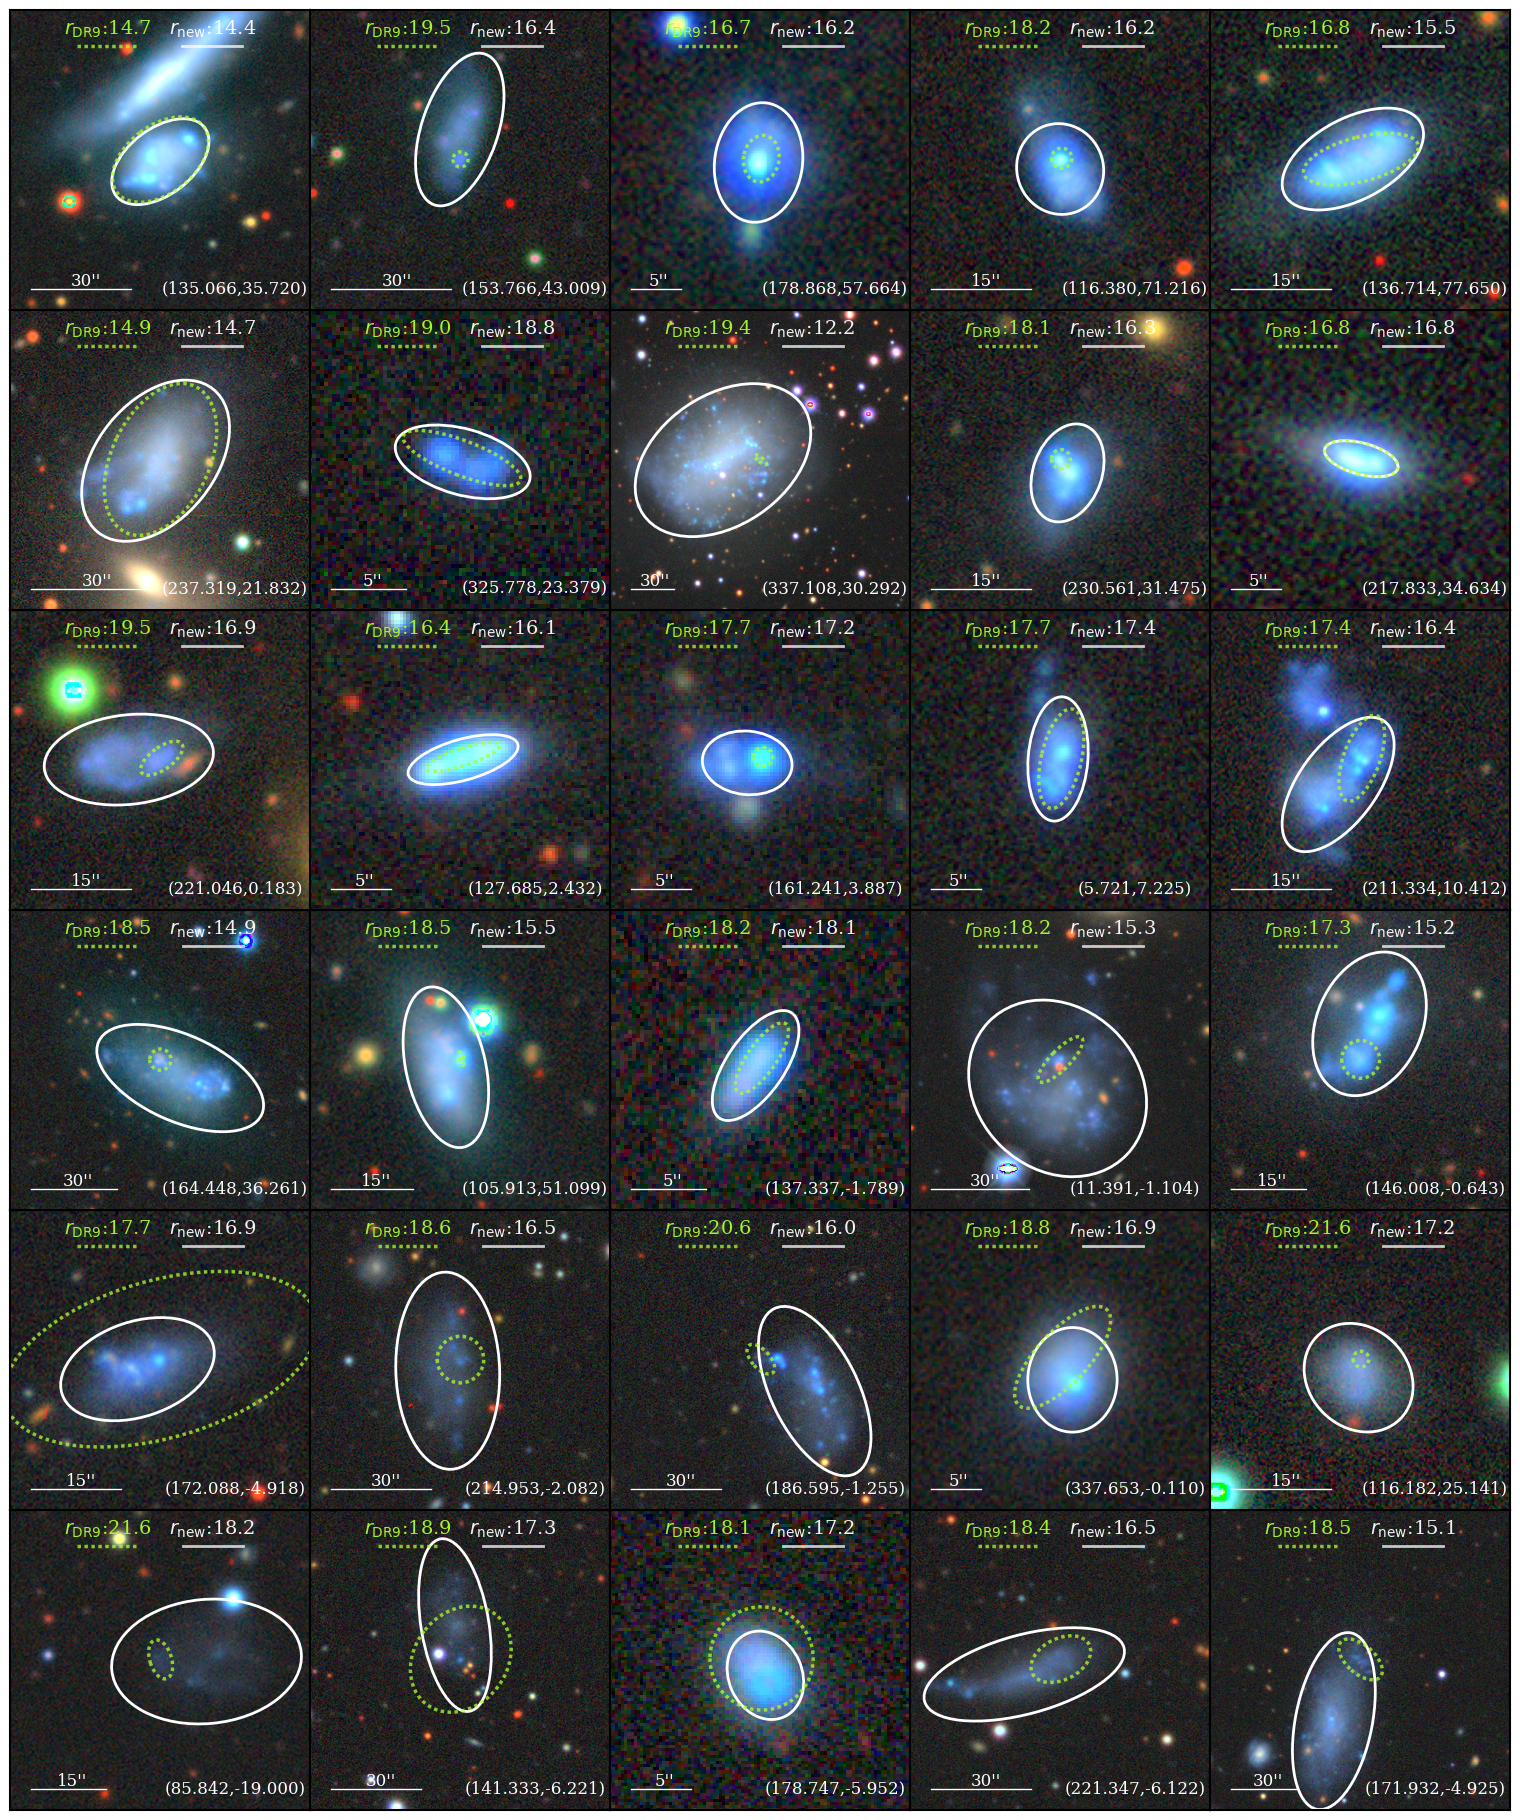

In [14]:
fig,ax = make_subplots(ncol=5,nrow=6,return_fig=True,col_spacing=0,row_spacing=0)

cutouts = [60]*len(plot_cat)


####

cutouts[12+0] = 20
cutouts[12+1] = 105
cutouts[12+2] = 60
cutouts[12+3] = 45
cutouts[12+4] = 25
cutouts[12+5] = 25


cutouts[12+6] = 30
cutouts[12+7] = 45
cutouts[12+8] = 75
cutouts[12+9] = 20
cutouts[12+10] = 210
cutouts[12+11] = 45

cutouts[12+12] = 30
cutouts[12+13] = 90
cutouts[12+14] = 75
cutouts[12+15] = 30
cutouts[12+16] = 45
cutouts[12+17] = 45

####
cutouts[0] = 60
cutouts[1] = 100
cutouts[2] = 25
cutouts[3] = 90
cutouts[4] = 135
cutouts[5] = 50

##

cutouts[6] = 90
cutouts[7] = 100
cutouts[8] = 30
cutouts[9] = 45
cutouts[10] = 105

#
cutouts[11] = 55

for i in range(len(plot_cat)):

    if cutouts[i] >= 75:
        bar_size = 30
    elif cutouts[i] >= 45:
        bar_size = 15
    else:
        bar_size = 5
    
    plot_one_panel([ax[i]],plot_cat["TARGETID"][i], plot_cat,
                      alpha=0.75,linewidth=2,
                      new_ls = "-", new_color = "white",
                        trac_ls  = (0,(1,1)), trac_color="greenyellow",
                      scale_f = 2, cutout_size_arcsec = cutouts[i],
                      bar_size_arc=bar_size, bar_size_str=f"{bar_size}''")


for axi in ax:
    axi.set_xticks([])
    axi.set_yticks([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_catalog_visuals.pdf",bbox_inches="tight")

plt.show()

In [15]:
def hires_cutout(ax,targetid, new_cat, cutout_size_arcsec):
    '''
    Function that plots a cutout and our new aperture on it!!
    '''

    index = np.where(new_cat["TARGETID"] == targetid)[0][0]

    #get the 3 different photometry!!

    #get image and wcs infno
    img_path = new_cat[index]["IMAGE_PATH"]
    hdus = fits.open(img_path)
    img_data = hdus[0].data
    wcs = WCS(fits.getheader( img_path))
    
    #finalize the cutout size
    cutout_size_pix  = int(cutout_size_arcsec/0.262)

    cutout_size_pix = np.minimum(cutout_size_pix, img_data.shape[1])
   
    #get the cutout image
    rgb_img, shift = process_img(img_data, cutout_size = cutout_size_pix, org_size = np.shape(img_data)[1], return_shift=True )

    ax[0].imshow(rgb_img, origin="lower")

    for axi in ax:
        axi.set_xticks([])
        axi.set_yticks([])
        axi.set_xlim([0,np.shape(rgb_img)[1]])
        axi.set_ylim([0,np.shape(rgb_img)[1]])
        
    return ax
    

In [33]:
## for all these objects let us save high-res cutouts of these

for i in range(len(plot_cat)):
    fig,ax = make_subplots(ncol=1,nrow=1,return_fig=True,plot_size=4)
    
    if cutouts[i] >= 75:
        bar_size = 30
    elif cutouts[i] >= 45:
        bar_size = 15
    else:
        bar_size = 5
    
    hires_cutout([ax[0]],plot_cat["TARGETID"][i], plot_cat, cutout_size_arcsec = cutouts[i] * 1.5 )

    plt.savefig(f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/pretty_dwarfs/dwarf_{i}.jpg",bbox_inches="tight",dpi=300)
    
    plt.close()

In [30]:
plot_cat[14]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_SAGA,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,IMAGE_PATH,SHAPE_R,BA,PHI
,,,,,,,,deg,deg,deg,deg,,Mpc,,,mag,mag,mag,mag,mag,mag,,,,,,,,,,,
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes10,int32,bytes13,bool,float32,float32[2],bool,bytes122,float32,float32,float32
39627769058951413,main,bright,27199,0.004846564883987,125117.68798027933,False,0.005990894391218138,146.00838091432524,-0.64274417673528,146.0088727980158,-0.6447167407608649,DESI J146.0088-00.6447,23.185415,7.9447513,8.104648,15.252567,15.209373,15.370726,17.22498,17.327793,17.59952,BGS_BRIGHT,0,COG,True,7.4967613,0.701928 .. 156.3761,True,/pscratch/sd/v/virajvm/redo_photometry_plots/all_sga_cutouts/image_tgid_39627769058951413_ra_146.009_dec_-0.645.fits,1.8909734,1.0,0.0


In [31]:
from desi_lowz_funcs import save_jpg
import requests

In [32]:
session = requests.Session()

In [34]:
save_jpg(146.0177, -0.6501, f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/pretty_dwarfs/dwarf_large.jpg", session, size = 1300)


In [35]:
save_jpg(132.9067, -2.3629, f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/pretty_dwarfs/dwarf_large_2.jpg", session, size = 1000)


In [36]:


save_jpg(357.9682, 0.7554, f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/pretty_dwarfs/dwarf_large_3.jpg", session, size = 500)
